## Topic analysis - Use case 1.

We do an unsupervised bertopic on four clusters that involve yielding, and analyse one of these where we focus on comparing it with structured data.
The results shown are for fictive data. 

### Data prep

In [21]:
import pandas as pd
import numpy as np
import plotly.express as px
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import random
import torch
import umap
import hdbscan
import json
from pathlib import Path
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
from bertopic.representation import KeyBERTInspired
from data_load import load_data_for_modeling
from embedding import load_sentence_embedding_model, generate_embeddings
from performance_index_bertopic import build_tokeniser, extract_topic_keywords, compute_coherence, compute_diversity
from bertopic_components import BERTopicConfig, run_bertopic
from sklearn.preprocessing import LabelEncoder 

In [22]:
from pathlib import Path

stopword_path = Path("final_stopwords.txt")

with open(stopword_path, encoding="utf-8") as f:
    stop_words = [
        line.strip()
        for line in f
        if line.strip()
    ]

print(f"Loaded {len(stop_words)} stop words.")

Loaded 681 stop words.


In [24]:
# Load data
data = pd.read_csv(
    "df_coords.csv"
)

In [25]:
# Load yielding topics
df1 = data[
    data["assigned_topic"].isin([0, 1])
].copy()

In [27]:
df1

,UHELDS_ID,accident_date,report_category,encoded_accident_situation,accident_situation,police_narrative,year,main_situation_class,n_words,UH_GEOMETRI,ADM_VEJ1_NR,KODE_UHELDKOMMUNE,X_KOORDINAT,Y_KOORDINAT,x,y,vejkode_clean,document_index,assigned_topic,assigned_topic_probability
0,1,2025-01-01,Mskpuh,398,398,This is narrative 1,2025,3,4,NaN,483721.0,101,NaN,NaN,12.600747,55.706911,3721.0,1,0,1.000000
1,2,2025-01-08,Anmsuh,170,170,This is narrative 2,2025,1,4,NaN,612945.0,147,NaN,NaN,12.523530,55.680005,2945.0,2,0,1.000000
2,3,2025-01-15,Pskduh,250,250,This is narrative 3,2025,2,4,NaN,751204.0,151,NaN,NaN,12.359738,55.733007,1204.0,3,0,1.000000
3,4,2025-01-22,Anmsuh,910,910,This is narrative 4,2025,9,4,NaN,394812.0,153,NaN,NaN,12.427277,55.622382,4812.0,4,1,1.000000
5,6,2025-02-05,Mskpuh,710,710,This is narrative 6,2025,7,4,NaN,547291.0,157,NaN,NaN,12.552647,55.750680,7291.0,6,0,1.000000
7,8,2025-02-19,Anmsuh,831,831,This is narrative 8,2025,8,4,NaN,912487.0,161,NaN,NaN,12.405387,55.683250,2487.0,8,0,1.000000
8,9,2025-02-26,Pskduh,140,140,This is narrative 9,2025,1,4,NaN,475638.0,163,536854.561,6348208.436,12.427167,55.734855,5638.0,9,1,1.000000
9,10,2025-03-05,Anmsuh,398,398,This is narrative 10,2025,3,4,NaN,358194.0,165,558514.560,6227161.259,12.351038,55.679580,8194.0,10,1,1.000000
10,11,2025-03-12,Anmsuh,999,999,This is narrative 11,2025,9,4,NaN,NaN,167,NaN,NaN,12.468732,55.630376,NaN,11,0,1.000000
11,12,2025-03-19,Mskpuh,740,740,This is narrative 12,2025,7,4,NaN,NaN,169,NaN,NaN,12.238677,55.659051,NaN,12,0,1.000000


In [29]:
# set seed to ensure reproducability
SEED = 42
 
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
 
set_seed()

# prep data
docs = df1["police_narrative"].reset_index(drop=True)
#labels = df1["label"].reset_index(drop=True)

# load embedding
MODEL_NAME = "KennethTM/MiniLM-L6-danish-encoder"

embedding_model = load_sentence_embedding_model(MODEL_NAME)
embeddings = generate_embeddings(
    docs=docs,
    embedding_model=embedding_model,
    batch_size=64,
    verbose=True,
)
print("step 1")
# load tokeniser for topic cohearence 
danish_stop_words = stop_words
tokenised, dictionary = build_tokeniser(
    docs,
    stop_words=danish_stop_words,
    min_df=2,
    ngram_range=(1, 2),
)
print("step 2")

# output base folder
BASE_PATH = Path("unsupervised_vigepligt")
BASE_PATH.mkdir(parents=True, exist_ok=True)

run_path = BASE_PATH / "unsupervised"
run_path.mkdir(parents=True, exist_ok=True)


# metrics changed for fake data
# define config
cfg = BERTopicConfig(
    mode="unsupervised",
    n_neighbors=3,
    n_components=5,
    min_dist=0.01,
    min_cluster_size=5,
    min_samples=5,
    stop_words=danish_stop_words,
    min_df=2,
    ngram_range=(1, 2),
    top_n_words=2,
)

# load model
model, topics, probs = run_bertopic(
    cfg,
    docs,
    embeddings,
    embedding_model
)

# save results in folder in mnt/raid/
df_results = pd.DataFrame({
    "document_index": np.arange(len(docs)),
    "assigned_topic": topics,
    "assigned_topic_probability": probs
})

df_results.to_csv(run_path / "document_topics.csv", index=False)

topic_info = model.get_topic_info()
topic_info.to_csv(run_path / "topic_info.csv", index=False)

topic_keywords = extract_topic_keywords(model, top_n=10)

topic_coherence = compute_coherence(
    topic_keywords,
    tokenised,
    dictionary
)

topic_diversity = compute_diversity(topic_keywords)

topic_dict = {}
for topic_id in topic_info["Topic"]:
    if topic_id == -1:
        continue

    words_scores = model.get_topic(topic_id)

    topic_dict[str(topic_id)] = [
        {"word": word, "score": float(score)}
        for word, score in words_scores
    ]

with open(run_path / "topic_words.json", "w") as f:
    json.dump(topic_dict, f, indent=2)

n_topics = topic_info.shape[0] - 1
n_outliers = (np.array(topics) == -1).sum()
noise_ratio = n_outliers / len(topics)
dbcv_score = model.hdbscan_model.relative_validity_

# metrics changed for fake data
metrics = {
    "n_topics": n_topics,
    "n_outliers": int(n_outliers),
    "noise_ratio": float(noise_ratio),
    "dbcv_score": float(dbcv_score),
    "topic_coherence": topic_coherence,
    "topic_diversity": topic_diversity,
    "top_k": 2,
    "umap_n_neighbors": 3,
    "umap_n_components": 5,
    "umap_min_dist": 0.01,
    "hdbscan_min_cluster_size": 5,
    "hdbscan_min_samples": 5,
}

with open(run_path / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)


Loading embedding model...
Loaded embedding model: KennethTM/MiniLM-L6-danish-encoder
Generating document embeddings...
(This may take a few minutes depending on dataset size)


Batches: 100%|██████████| 1/1 [00:00<00:00, 25.81it/s]
2026-06-30 10:52:25,232 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 10:52:25,265 - BERTopic - Dimensionality - Completed ✓
2026-06-30 10:52:25,266 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 10:52:25,268 - BERTopic - Cluster - Completed ✓
2026-06-30 10:52:25,269 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-30 10:52:25,279 - BERTopic - Representation - Completed ✓
2026-06-30 10:52:25,279 - BERTopic - Topic reduction - Reducing number of topics
2026-06-30 10:52:25,286 - BERTopic - Representation - Fine-tuning topics using representation models.


Embedding shape: (46, 384)
step 1
step 2


2026-06-30 10:52:26,003 - BERTopic - Representation - Completed ✓
2026-06-30 10:52:26,004 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoi

### Analyze the new subtopics:

In [32]:
subtopics = pd.read_csv(
    "unsupervised_vigepligt/unsupervised/document_topics.csv"
)

In [33]:
df1 = df1.reset_index(drop=True)
df1["topic"] = subtopics["assigned_topic"]

In [34]:
df1[df1["topic"] == 1]["main_situation_class"].value_counts().sort_index()

main_situation_class
0    1
2    1
3    1
6    1
8    3
9    1
Name: count, dtype: int64

In [35]:
vigepligt = pd.read_excel(
    "vigepligt.xlsx",
    header=2
)

In [36]:
vigepligt.loc[vigepligt["ELEMENTNR"].idxmax()]

UHELDS_ID        1
ELEMENTNR        3
VIGEPLIGT    Ingen
Name: 2, dtype: object

In [37]:
vigepligt_wide = (
    vigepligt
    .pivot_table(
        index="UHELDS_ID",
        columns="ELEMENTNR",
        values="VIGEPLIGT",
        aggfunc="first"
    )
)

vigepligt_wide.columns = [
    f"vigepligt_element_{int(col)}" for col in vigepligt_wide.columns
]

vigepligt_wide = vigepligt_wide.reset_index()

In [38]:
df1 = df1.merge(
    vigepligt_wide,
    on="UHELDS_ID",
    how="left"
)

In [39]:
topic_names = {
    0: "Turning / Yielding Conflicts",
    1: "parked",
    2: "Signalized Intersections",
    4: "Hajtænder / Yield Lines",
    3: "Ligeud",
    5: "krydset",
    -1: "Outliers"
}

df1["topic_name"] = (
    df1["topic"]
    .map(topic_names)
)

In [41]:
# count Topic 2 crashes per year since 1985
topic2_yearly = (
    df1[df1["topic"] == 2]
    .groupby("year")
    .size()
    .reset_index(name="count")
)

# keep only years from 1985 onward
topic2_yearly = topic2_yearly[
    topic2_yearly["year"] >= 1985
]

In [42]:
topic2_yearly

,year,count
0,2025,7


In [43]:
vigepligt_values = ["U.vp. afm", "U.vp. Iøv."]

vigepligt_crash_level = (
    vigepligt
    .assign(structured_vigepligt=vigepligt["VIGEPLIGT"].isin(vigepligt_values))
    .groupby("UHELDS_ID", as_index=False)
    .agg(structured_vigepligt=("structured_vigepligt", "max"))
)

In [44]:
df1 = df1.merge(
    vigepligt_crash_level,
    on="UHELDS_ID",
    how="left"
)

df1["structured_vigepligt"] = df1["structured_vigepligt"].fillna(False)

In [45]:
topic_hajtaender_not_structured = df1[
    (df1["topic"] == 2) &
    (df1["structured_vigepligt"] == False)
].copy()

In [46]:
topic4 = set(df1.loc[df1["topic"] == 4, "UHELDS_ID"])
structured_ids = set(df1.loc[df1["structured_vigepligt"] == True, "UHELDS_ID"])

overlap_ids = topic4 & structured_ids

print("Structured vigepligt total:", len(structured_ids))
print("Overlap:", len(overlap_ids))

Structured vigepligt total: 8
Overlap: 0


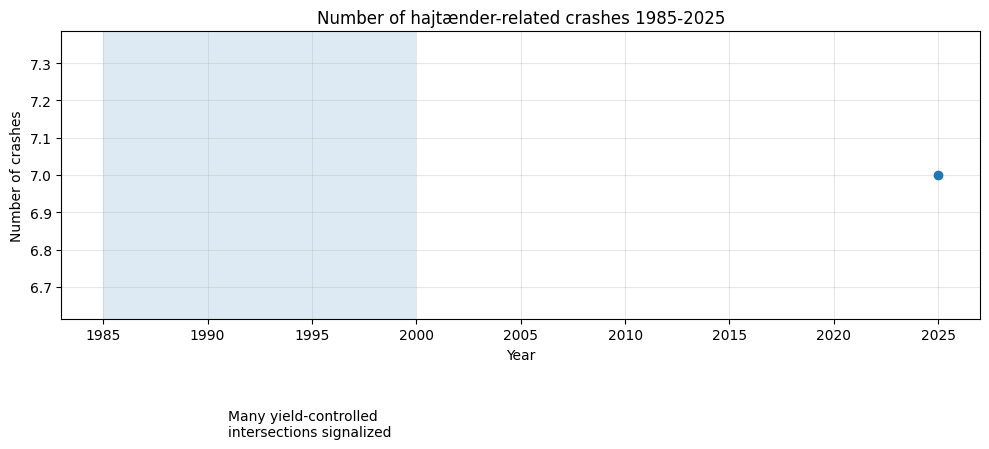

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    topic2_yearly["year"],
    topic2_yearly["count"],
    marker="o",
    linewidth=2
)

# Highlight period where many intersections were signalized
plt.axvspan(1985, 2000, alpha=0.15)

plt.text(
    1991,
    topic2_yearly["count"].max() * 0.9,
    "Many yield-controlled\nintersections signalized",
    fontsize=10
)

plt.title("Number of hajtænder-related crashes 1985-2025")
plt.xlabel("Year")
plt.ylabel("Number of crashes")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusions:

The analysis demonstrates that BERTopic can support validation of structured crash data by identifying crashes where the narratives consistently describe a right-of-way situation despite the absence of the corresponding structured classification. Rather than introducing new crash categories, the topic model highlights records that may warrant further review.